<a href="https://colab.research.google.com/github/JillFang1030/BrainHack_Final_Project/blob/main/Revised_Final_Project_BrainHack_intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Project

# Plotting



*   Make an interactive plot using plotly with my project data.
*   TD: typically developed; DD: dyslexia

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
## Exercise 4 (TD: typically developed; DD: dyslexia)
import pandas as pd
import plotly.express as px

# 1. load data
df_dd = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/DD_for_project.xlsx')
df_td = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/TD_for_project.xlsx')

# 2. Label
df_dd['Group'] = 'DD'
df_td['Group'] = 'TD'

# 3. Merge
df_project = pd.concat([df_dd, df_td], ignore_index=True)

# 4. 印出所有欄位名稱
print("合併後的欄位有：\n", df_project.columns.tolist())

合併後的欄位有：
 ['ID', 'C_MC', 'C_CTOPP', 'C_RAN', 'C_CR', 'C_WR', 'C_PIC', 'C_PIC (52)', 'C_RF', 'RF_inc_w/o skip', 'RF_inc_w/ skip', 'Character_recog (raw score)', 'Character_recog (PR)', "IQ_Raven's (raw)", "IQ_Raven's (Standard)", 'fNIRS_Date1', 'Chinese_MAPA', 'Story_Listening', 'Chinese_Priming', 'Chinese_semantic', 'Resting', 'Chinese_RAN', 'fNIRS_Date2', 'Chinese_MAPA.1', 'Story_Listening.1', 'Chinese_Priming.1', 'Chinese_semantic.1', 'Resting.1', 'Chinese_RAN.1', 'Group', 'C_PIC(52)', 'RF_inc_w/o_skip', 'RF_inc_w/_skip', 'Chinese_Semantic']


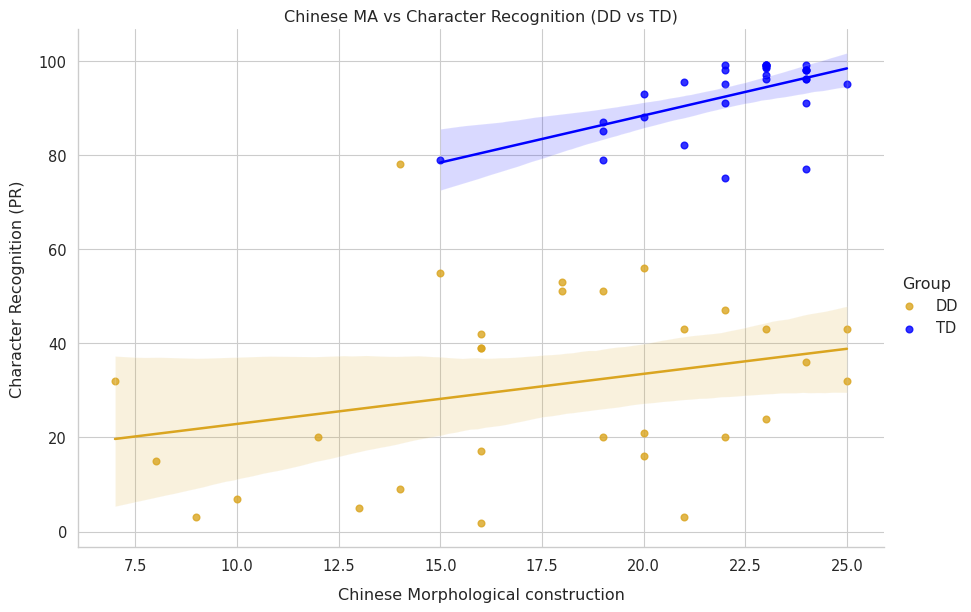

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# 設定背景
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.2)

# 使用 lmplot 自動畫出散佈圖與趨勢線
sns.lmplot(
    data=df_project,
    x='C_MC',               # X軸：Chinese Morphological construction
    y='Character_recog (PR)',# Y軸：中文字認讀分數
    hue='Group',                    # 顏色：DD vs TD
    palette=['goldenrod', 'blue'],        # DD 用金色，TD 用藍色
    height=6,                       # 圖片高度
    aspect=1.5                      # 圖片長寬比
)

plt.xlabel('Chinese Morphological construction', labelpad=10)
plt.ylabel('Character Recognition (PR)', labelpad=10)

# 儲存圖片
# bbox_inches='tight' 可以確保圖片邊緣的字不會被意外切掉
plt.savefig('my_research_plot.png', dpi=300, bbox_inches='tight')

plt.title('Chinese MA vs Character Recognition (DD vs TD)')
plt.show()

# 畫完重置設定
sns.reset_orig()

In [4]:
import plotly.express as px

# 用 Plotly 畫出 MA 與認字分數的關係，並加上趨勢線
fig = px.scatter(
    df_project,
    x='C_MC',
    y='Character_recog (PR)',
    color='Group',
    trendline="ols",                # Plotly 也能畫趨勢線 (OLS 迴歸線)
    hover_data=['ID'], # 游標移上去可以看到學生 ID
    labels={'C_MC': 'Chinese MA (C_MC)', 'Character_recog (raw score)': 'Character Recognition (Raw)'},
    title='Interactive Chinese MA vs Character Recognition (DD vs TD)',
    template='plotly_white',        # 乾淨的白色背景
    color_discrete_map={'DD': 'goldenrod', 'TD': 'blue'}
)

fig.show()
fig.write_html("my_interactive_plot.html")

# Correlation





In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

# 設定資料夾路徑
folder_path = '/content/drive/MyDrive/Colab Notebooks/'

# --- 1. 直接指定你目前的檔案名稱 ---
try:
    # 讀取 Beta 資料 (CSV 格式)
    df_beta_dd = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Beta_DD.csv')
    df_beta_td = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Beta_TD.csv')

    # 讀取行為指標資料 (Excel 格式)
    df_behav_dd = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/DD_for_project.xlsx')
    df_behav_td = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/TD_for_project.xlsx')

    print("✅ 所有檔案（CSV 與 Excel）讀取成功")
except Exception as e:
    print(f"❌ 讀取失敗：{e}")
    raise

✅ 所有檔案（CSV 與 Excel）讀取成功


In [7]:
# 2. 欄位標頭清洗 (清除隱形空格，防止抓不到 Character_recog (PR)) ---
for df in [df_beta_dd, df_beta_td, df_behav_dd, df_behav_td]:
    df.columns = df.columns.str.strip()

# 3. 處理 Beta 值 (提取 Channel 6, 16, 21 的 MA 條件)，合併兩組 Beta 資料
beta_all = pd.concat([df_beta_dd, df_beta_td], ignore_index=True)

# 篩選特定頻道與條件 (只選 cond 為 MA)
target_channels = [6, 16, 21]
beta_filtered = beta_all[(beta_all['Channel'].isin(target_channels)) & (beta_all['cond'] == 'MA')]

# 將長格式轉為寬格式：讓 Subject 變回 ID 欄位，Channel 數字變為標題
beta_pivot = beta_filtered.pivot_table(index='Subject', columns='Channel', values='Beta').reset_index()
beta_pivot.columns = ['ID', 'Beta_CH6', 'Beta_CH16', 'Beta_CH21']

In [8]:
# --- 4. 合併行為指標 ---
# 合併兩組行為資料
behavior_all = pd.concat([df_behav_dd, df_behav_td], ignore_index=True)

# 提取 ID, C_MC 以及 Character_recog (PR)
# 注意：C_MC 在資料中代表 Morphological Construction
behavior_subset = behavior_all[['ID', 'C_MC', 'Character_recog (PR)']].copy()
# 要看完整行為指標名單做相關
target_behaviors = [
    'C_MC', 'Character_recog (PR)', 'C_CTOPP', 'C_RAN',
    'C_CR', 'C_WR', 'C_PIC', 'C_PIC (52)', 'C_RF'
]

In [9]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
import statsmodels.stats.multitest as smm


# 1. 撈取所有 9 個行為指標
# 合併兩組行為原始資料
behavior_all = pd.concat([df_behav_dd, df_behav_td], ignore_index=True)

# 已加入新加的所有指標
target_behaviors = [
    'C_MC', 'Character_recog (PR)', 'C_CTOPP', 'C_RAN',
    'C_CR', 'C_WR', 'C_PIC', 'C_PIC (52)', 'C_RF'
]

# 提取 ID 以及所有我們要分析的行為指標
behavior_subset = behavior_all[['ID'] + target_behaviors].copy()

# 確保大腦表（beta_pivot）與行為表的 ID 型別一致（都轉成整數）
beta_pivot['ID'] = beta_pivot['ID'].astype(int)
behavior_subset['ID'] = behavior_subset['ID'].astype(int)

# 透過 ID 把大腦 Beta 資料與行為分數資料拼在一起（注意：大表不預先做整體 dropna）
final_df = pd.merge(beta_pivot, behavior_subset, on='ID', how='inner')



# 2. 定義全新相關分析引擎（個別 dropna 機制，外加 FDR 校正）
def run_correlation_with_fdr(df, channels, behaviors):
    results = []
    raw_p_values = [] # 用來存取所有的原始 p 值

    # 計算 3 個 Channel × 9 個指標 = 27 次 Pearson 相關
    for ch in channels:
        for bh in behaviors:
            if ch in df.columns and bh in df.columns:
                # 💡 【自動防錯核心】：只針對目前計算的這對指標個別去除缺失值，保留最多受試者
                valid_data = df[[ch, bh]].dropna()

                # 💡 【長度檢查】：確保人數夠才計算（長度大於 2），不夠就填空值，不讓程式死當
                if len(valid_data) > 2:
                    r_val, p_val = pearsonr(valid_data[ch], valid_data[bh])
                else:
                    r_val, p_val = np.nan, np.nan
            else:
                r_val, p_val = np.nan, np.nan

            results.append({
                'Channel': ch,
                'Behavior': bh,
                'Pearson_r': round(r_val, 3) if not np.isnan(r_val) else np.nan,
                'p_value_raw': round(p_val, 4) if not np.isnan(p_val) else np.nan
            })
            # 將 p 值存入清單。如果是 nan 則用 1.0 代替，確保校正不報錯
            raw_p_values.append(1.0 if np.isnan(p_val) else p_val)

    # 進行這 27 次比較的 FDR 多重比較校正
    reject, p_corrected, _, _ = smm.multipletests(raw_p_values, alpha=0.05, method='fdr_bh')

    # 將校正結果塞回表格
    for idx, res in enumerate(results):
        res['p_value_FDR_corrected'] = round(p_corrected[idx], 4)
        res['Significant_After_FDR'] = '★ TRUE' if reject[idx] else ''
        p_raw = res['p_value_raw']
        res['Significant_Raw'] = '*' if (p_raw is not None and p_raw < 0.05) else ''

    return pd.DataFrame(results)


# 3. 執行分析：計算整體的 27 行總表

target_channels_short = ['Beta_CH6', 'Beta_CH16', 'Beta_CH21']

# 3-1. 跑全體的相關分析
print("========== 全體兒童（N=30）27次相關分析結果 ==========")
analysis_results_all = run_correlation_with_fdr(final_df, target_channels_short, target_behaviors)
print(analysis_results_all.to_string(index=False))
analysis_results_all.to_excel('All_subjects_3ch_9behav_results.xlsx', index=False)

print("\n" + "="*80 + "\n")

========== 全體兒童（N=30）27次相關分析結果 ==========
  Channel             Behavior  Pearson_r  p_value_raw  p_value_FDR_corrected Significant_After_FDR Significant_Raw
 Beta_CH6                 C_MC      0.045       0.7345                 0.9711                                      
 Beta_CH6 Character_recog (PR)     -0.116       0.3764                 0.9711                                      
 Beta_CH6              C_CTOPP      0.017       0.8991                 0.9711                                      
 Beta_CH6                C_RAN     -0.004       0.9782                 0.9782                                      
 Beta_CH6                 C_CR     -0.108       0.4124                 0.9711                                      
 Beta_CH6                 C_WR     -0.040       0.7625                 0.9711                                      
 Beta_CH6                C_PIC     -0.085       0.5163                 0.9711                                      
 Beta_CH6           C_PIC (52)

In [10]:
# 導出：將全體兒童的 27 行相關分析結果存成 Excel 檔案
excel_filename = 'All_Subjects_60_Correlation_Results.xlsx'

analysis_results_all.to_excel(excel_filename, index=False)

print("\n" + "="*60)
print(f"🎉 全體兒童 Excel 表格已成功導出！")
print(f"📁 檔案名稱：{excel_filename}")
print("💡 說明：請點開 Colab 左側的小資料夾，就能直接下載囉！")
print("="*60)


🎉 全體兒童 Excel 表格已成功導出！
📁 檔案名稱：All_Subjects_60_Correlation_Results.xlsx
💡 說明：請點開 Colab 左側的小資料夾，就能直接下載囉！


只有CH16的C_PIC (52)有超級微小的顯著

In [11]:
# 3-2. 拆分兩組，分別計算各自的相關性
#dd_ids = df_behav_dd['ID'].unique()
#td_ids = df_behav_td['ID'].unique()

#df_dd_only = final_df[final_df['ID'].isin(dd_ids)]
#df_td_only = final_df[final_df['ID'].isin(td_ids)]

#print("========== DD 組 (閱讀障礙) 27次相關分析結果 ==========")
#results_dd = run_correlation_with_fdr(df_dd_only, target_channels_short, target_behaviors)
#print(results_dd.to_string(index=False))
#results_dd.to_excel('DD_3ch_9behav_results.xlsx', index=False)

#print("\n" + "="*80 + "\n")

#print("========== TD 組 (典型發展) 27次相關分析結果 ==========")
#results_td = run_correlation_with_fdr(df_td_only, target_channels_short, target_behaviors)
#print(results_td.to_string(index=False))
#results_td.to_excel('TD_3ch_9behav_results.xlsx', index=False)

#print("\n🎉 【表格計算完畢且已自動存檔】：全體、DD、TD 三張 Excel 表已成功導出！")

### **5. Exploratory Whole-Brain Correlation Analysis (Methodological Upgrade)**

> **A Note on Avoiding "Double Dipping" (Selection Bias):**
> After discussion with TA, we implemented a major methodological upgrade for the brain-behavior correlation analysis to ensure strict statistical independence.
>
> The reason is that originally, our pipeline performed a ROI-based (cherry-picked) correlation using only the channels that showed significant group differences in the LME stage (Channels 6, 16, 21). However, this introduces a form of **Double Dipping (Selection Bias)** and poses a logical mismatch:
> * **Methodological Bias:** Selecting channels based on LME group differences first, and then running downstream Pearson's $r$ on those same channels, artificially inflates the statistical power and often serves as a subconscious workaround to avoid a stringent round of multi-comparison corrections.
> * **Logical Mismatch:** The LME predictors reflect trial block conditions (group-by-condition interactions), whereas the Pearson's $r$ variables are behavioral task scores collected independently. A channel showing group differences in task activation does *not* inherently guarantee a linear brain-behavior relationship, and vice versa (channels with non-significant LME results might actually possess strong correlations with behavior).

#### **To Optimize:**
To build a methodologically cleaner inference, I took Amanda's advice and expanded our analysis to an **independent whole-brain exploration**:
1. **Visualizing Data Layout (8x4 Subplots Matrix):** generated an 8×4 matplotlib subplots grid to loop through **all 32 channels**, plotting behavioral data (`Character_recog (PR)`) against individual Betas to visually inspect whether the underlying relationships are genuinely linear.
2. **Whole-Brain Correction:** Instead of avoiding correction, I ran Pearson's $r$ across all 32 channels simultaneously and applied a rigorous **FDR (False Discovery Rate) correction** directly within Python to control for multiple comparisons.

---

正在建立 8x4 散佈圖矩陣 (對應 Character_recog (PR))...
🎉 Image saved: whole_brain_32_channels_scatter_plots.png


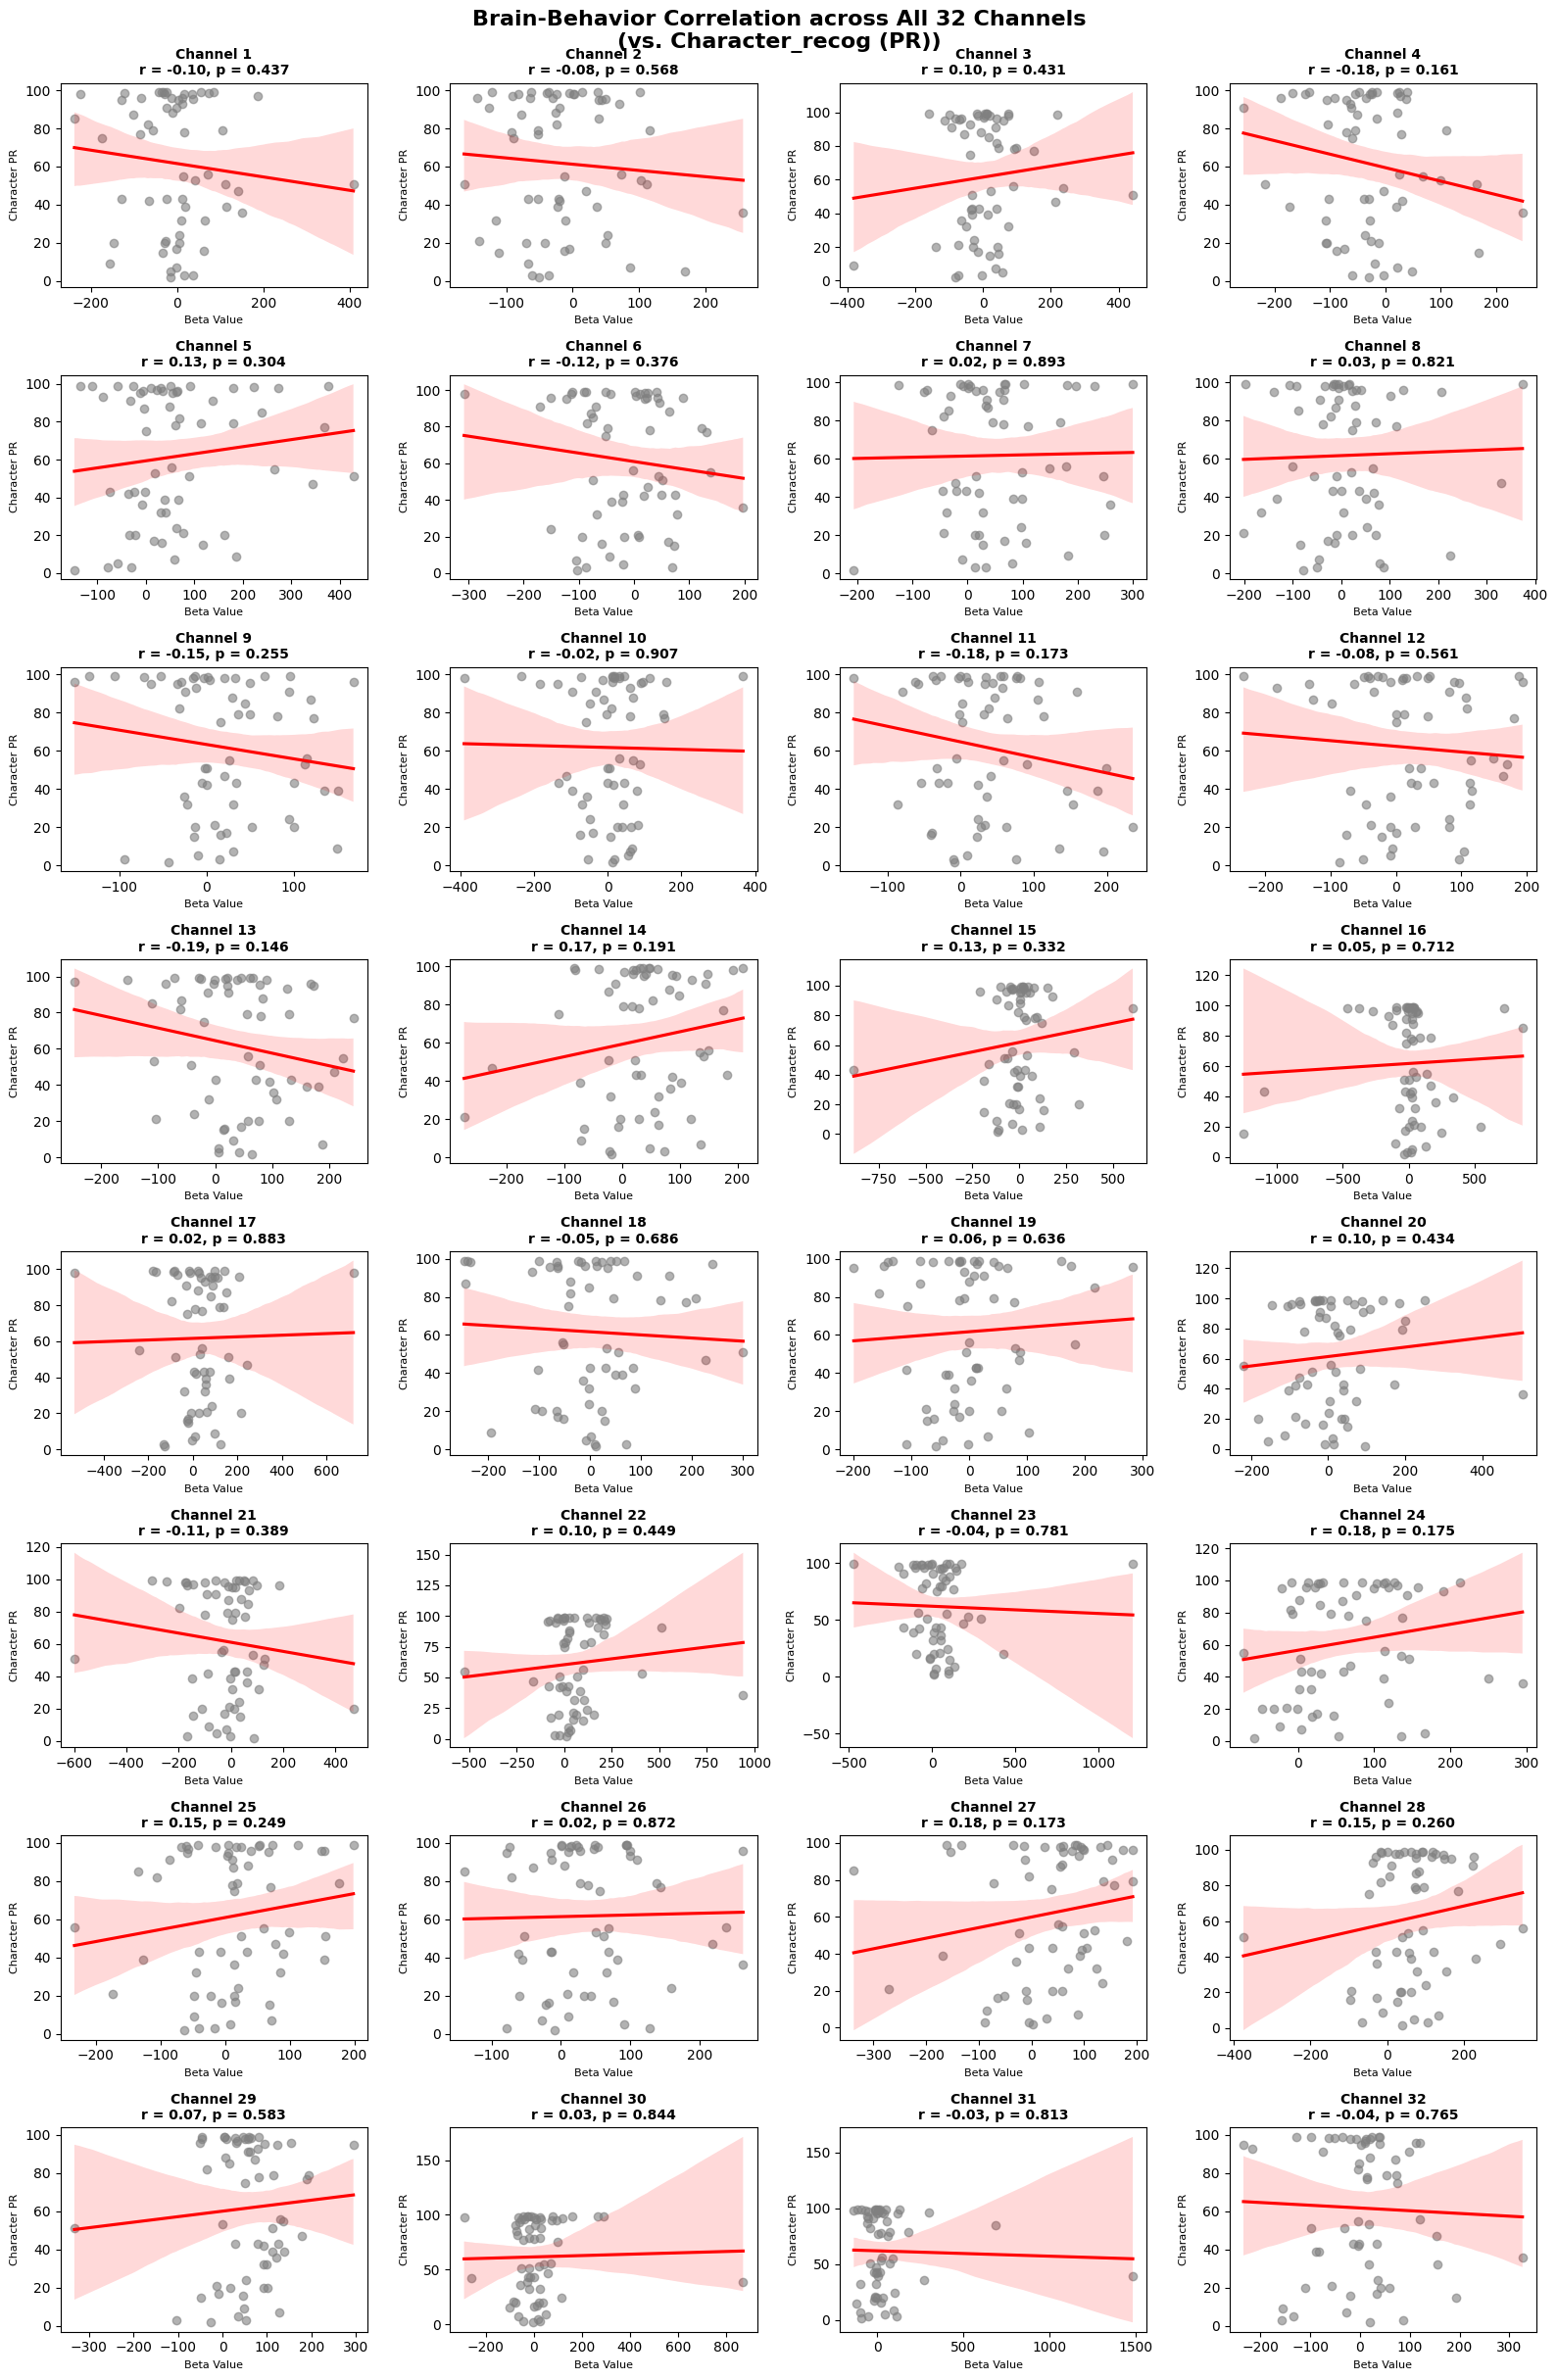


=== 全腦 32 Channel FDR 校正總表 (vs. 識字量 PR) ===
 Channel  Pearson_r  p_value_raw  p_value_FDR_corrected  Significant_After_FDR
       1  -0.102178     0.437243               0.844600                  False
       2  -0.075185     0.568043               0.907145                  False
       3   0.103563     0.431025               0.844600                  False
       4  -0.183235     0.161103               0.844600                  False
       5   0.134809     0.304439               0.844600                  False
       6  -0.116264     0.376354               0.844600                  False
       7   0.017681     0.893336               0.907145                  False
       8   0.029804     0.821157               0.907145                  False
       9  -0.149366     0.254681               0.844600                  False
      10  -0.015381     0.907145               0.907145                  False
      11  -0.178308     0.172863               0.844600                  False
      1

In [12]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
import statsmodels.stats.multitest as smm
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 篩選大腦資料：所有 32 個 Channel，但條件固定為 'MA'
beta_ma_all = beta_all[beta_all['cond'] == 'MA'].copy()

# 將資料從長格式轉為寬格式（讓 32 個 Channel 變成獨立的 32 欄）
beta_pivot_32 = beta_ma_all.pivot_table(index='Subject', columns='Channel', values='Beta').reset_index()

# 確保 ID 的欄位名稱與型態與行為資料一致
beta_pivot_32.rename(columns={'Subject': 'ID'}, inplace=True)
beta_pivot_32['ID'] = beta_pivot_32['ID'].astype(int)

# 提取行為指標資料 (ID, 形態覺察 C_MC, 識字量 Character_recog (PR))
behavior_subset_32 = behavior_all[['ID', 'C_MC', 'Character_recog (PR)']].copy()
behavior_subset_32['ID'] = behavior_subset_32['ID'].astype(int)

# 合併大腦與行為資料
final_df_32 = pd.merge(beta_pivot_32, behavior_subset_32, on='ID', how='inner')

# 自動抓出所有 32 個 Channel 的欄位名稱
channels = sorted([ch for ch in beta_pivot_32.columns if ch != 'ID'])


# 2. 建立一個 8 橫列 × 4 縱行 的 matplotlib subplots
fig, axes = plt.subplots(8, 4, figsize=(16, 24), sharex=False, sharey=False)
axes = axes.flatten()

p_values_character = []
r_values_character = []

print("正在建立 8x4 散佈圖矩陣 (對應 Character_recog (PR))...")

# Plotting with loop
for i, ch in enumerate(channels):
    # 清除缺失值
    valid_data = final_df_32[['ID', ch, 'Character_recog (PR)']].dropna()

    x = valid_data[ch].values
    y = valid_data['Character_recog (PR)'].values

    # 計算 Pearson 相關
    if len(x) > 2:
        r, p = pearsonr(x, y)
    else:
        r, p = np.nan, np.nan

    r_values_character.append(r)
    p_values_character.append(p)

    # 畫散佈圖與紅色趨勢線
    sns.regplot(x=x, y=y, ax=axes[i],
                scatter_kws={'alpha':0.6, 'color':'gray'},
                line_kws={'color':'red'})

    # 設定每格小標題：顯示 Channel 數字、r值與原始 p值
    axes[i].set_title(f'Channel {ch}\nr = {r:.2f}, p = {p:.3f}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Beta Value', fontsize=8)
    axes[i].set_ylabel('Character PR', fontsize=8)

# 調整畫布排版
plt.tight_layout()
plt.suptitle('Brain-Behavior Correlation across All 32 Channels\n(vs. Character_recog (PR))',
             y=1.01, fontsize=16, fontweight='bold')

# 新增存檔指令：把 32 張大圖存成高解析度的 PNG 圖檔；pi=300 可以確保圖片放大放進 PPT 或 Word 時比較不會模糊！
plt.savefig('whole_brain_32_channels_scatter_plots.png', dpi=300, bbox_inches='tight')
print("🎉 Image saved: whole_brain_32_channels_scatter_plots.png")

plt.show()
# 3. 統計校正：對 32 個 p 值進行 FDR 校正
p_values_clean = [0.999 if np.isnan(v) else v for v in p_values_character]
reject, p_corrected, _, _ = smm.multipletests(p_values_clean, alpha=0.05, method='fdr_bh')

# 製作成表格
results_df = pd.DataFrame({
    'Channel': channels,
    'Pearson_r': r_values_character,
    'p_value_raw': p_values_character,
    'p_value_FDR_corrected': p_corrected,
    'Significant_After_FDR': reject
})

print("\n" + "="*50)
print("=== 全腦 32 Channel FDR 校正總表 (vs. 識字量 PR) ===")
print("="*50)
print(results_df.to_string(index=False))

sig_channels = results_df[results_df['Significant_After_FDR'] == True]['Channel'].tolist()
if len(sig_channels) > 0:
    print(f"\n🎉 Great! After FDR correction, the significant channels are: {sig_channels}")
else:
    print(f"\nOops! After FDR correction, no channels survived. See scatter plot.")

# 把 FDR 校正總表存成 Excel 檔
results_df.to_excel('whole_brain_fdr_correction_results.xlsx', index=False)
print("🎉 【表格已自動存檔】：whole_brain_fdr_correction_results.xlsx")

⏳ 正在計算全腦 32通道 ✕ 9指標 的 288 次相關矩陣...
🎉 【全腦全指標熱圖已成功存檔】：whole_brain_32ch_9behav_heatmap.png


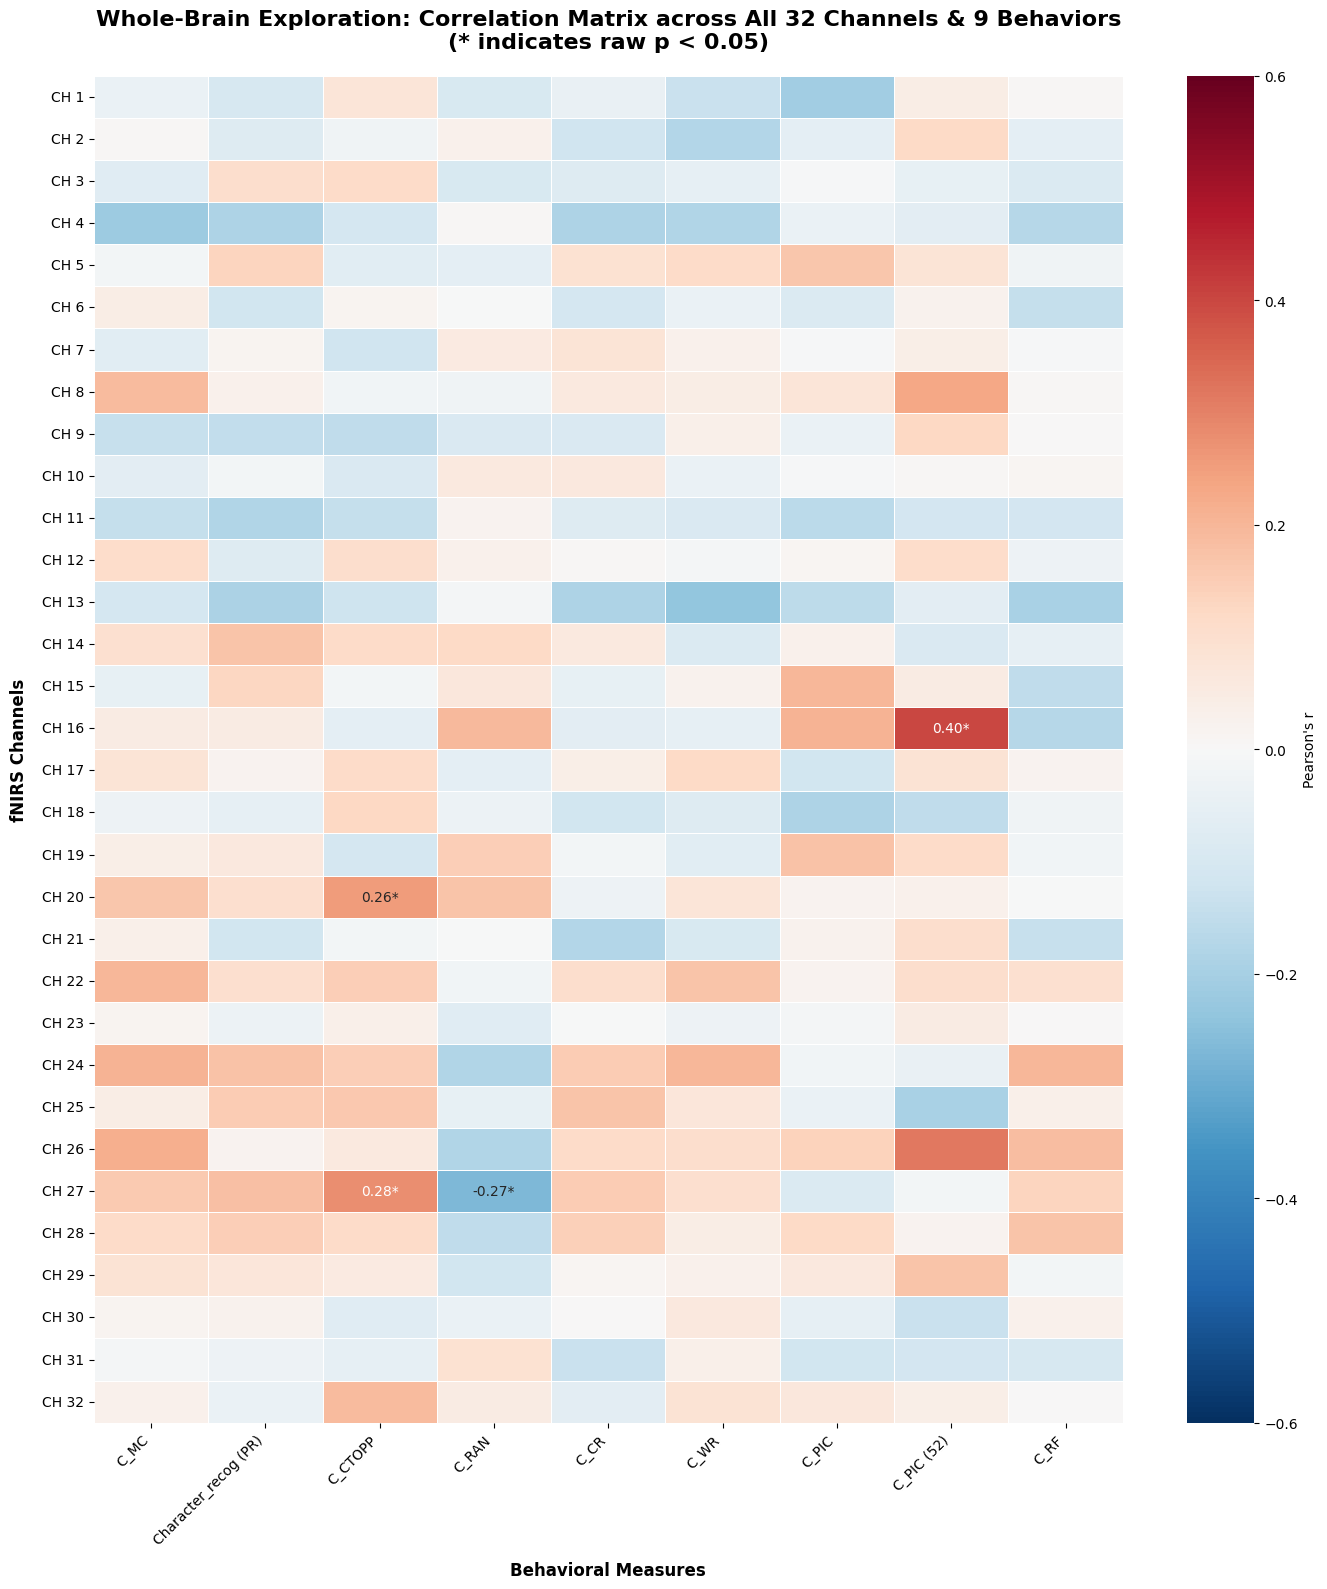

🎉 【全腦288行原始統計總表已自動存檔】：whole_brain_288_matrix_results.xlsx


In [13]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt

# =====================================================================
# 1. 整理全腦 32 通道與 9 個行為指標的合併大表
# =====================================================================
# 整理大腦 32 個 Channel (MA 條件)
beta_ma_all = beta_all[beta_all['cond'] == 'MA'].copy()
beta_pivot_32 = beta_ma_all.pivot_table(index='Subject', columns='Channel', values='Beta').reset_index()
beta_pivot_32.rename(columns={'Subject': 'ID'}, inplace=True)
beta_pivot_32['ID'] = beta_pivot_32['ID'].astype(int)

# 整理 9 個行為指標名單
target_behaviors = [
    'C_MC', 'Character_recog (PR)', 'C_CTOPP', 'C_RAN',
    'C_CR', 'C_WR', 'C_PIC', 'C_PIC (52)', 'C_RF'
]
behavior_subset_32 = behavior_all[['ID'] + target_behaviors].copy()
behavior_subset_32['ID'] = behavior_subset_32['ID'].astype(int)

# 合併成全腦大表
final_df_32 = pd.merge(beta_pivot_32, behavior_subset_32, on='ID', how='inner')
channels = sorted([ch for ch in beta_pivot_32.columns if ch != 'ID'])

# 2. 計算 32 通道 ✕ 9 指標 = 288 次相關，建立矩陣
print("⏳ 正在計算全腦 32通道 ✕ 9指標 的 288 次相關矩陣...")

# 建立用來畫熱圖的空矩陣
matrix_r = pd.DataFrame(index=[f'CH {ch}' for ch in channels], columns=target_behaviors)
matrix_annot = pd.DataFrame(index=[f'CH {ch}' for ch in channels], columns=target_behaviors)

results_list_288 = []

for ch in channels:
    for bh in target_behaviors:
        ch_name = ch  # 數字
        if ch_name in final_df_32.columns and bh in final_df_32.columns:
            valid_data = final_df_32[[ch_name, bh]].dropna()
            if len(valid_data) > 2:
                r_val, p_val = pearsonr(valid_data[ch_name], valid_data[bh])
            else:
                r_val, p_val = np.nan, np.nan
        else:
            r_val, p_val = np.nan, np.nan

        # 填入畫熱圖用的矩陣 (保留 r 值)
        matrix_r.loc[f'CH {ch}', bh] = r_val if not np.isnan(r_val) else 0.0

        # 💡 如果原始 p 值 < 0.05 且 r 有值，就在熱圖格子上標註星號和 r 值，其餘留白
        if not np.isnan(p_val) and p_val < 0.05:
            matrix_annot.loc[f'CH {ch}', bh] = f"{r_val:.2f}*"
        else:
            matrix_annot.loc[f'CH {ch}', bh] = ""

        # 存成 Excel 用的清單
        results_list_288.append({
            'Channel': f'CH {ch}',
            'Behavior': bh,
            'Pearson_r': round(r_val, 3) if not np.isnan(r_val) else np.nan,
            'p_value_raw': round(p_val, 4) if not np.isnan(p_val) else np.nan
        })

# 3. 繪製全腦全指標終極熱圖（Heatmap）
plt.figure(figsize=(14, 16))

# 將矩陣型態轉成 float 確保 seaborn 能讀懂
matrix_r = matrix_r.astype(float)

# 繪製熱圖：藍色代表負相關，紅色代表正相關，中間白色代表沒相關
sns.heatmap(matrix_r,
            annot=matrix_annot.values,
            fmt="",
            cmap='RdBu_r',
            vmin=-0.6, vmax=0.6,
            center=0.0,
            linewidths=0.5,
            cbar_kws={'label': "Pearson's r"})

plt.title('Whole-Brain Exploration: Correlation Matrix across All 32 Channels & 9 Behaviors\n(* indicates raw p < 0.05)',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Behavioral Measures', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('fNIRS Channels', fontsize=12, fontweight='bold', labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()

# 存檔為目標 3 通道熱圖
plt.savefig('target_3ch_9behav_heatmap.png', dpi=300, bbox_inches='tight')
print("🎉 【目標 3 通道熱圖已成功存檔】：target_3ch_9behav_heatmap.png")

plt.show()

# 4. 儲存 288 行總表成 Excel# =====================================================================
df_results_288 = pd.DataFrame(results_list_288)
df_results_288.to_excel('whole_brain_288_matrix_results.xlsx', index=False)
print("🎉 【全腦288行原始統計總表已自動存檔】：whole_brain_288_matrix_results.xlsx")